In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
df = pd.read_csv("../dataset/phishing_site_urls.csv")
df.head()

,url,label
0,https://www.visitcanada.com,legitimate
1,http://218.228.19.9/~yossi/9ssfpkz,phishing
2,https://www.msupress.msu.edu/series.php?series...,legitimate
3,https://docs.google.com/presentation/d/e/2PACX...,phishing
4,https://www.c250.columbia.edu/c250_celebrates/...,legitimate


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253098 entries, 0 to 253097
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     253098 non-null  object
 1   label   253098 non-null  object
dtypes: object(2)
memory usage: 3.9+ MB


In [4]:
df['label'].value_counts()

label
legitimate    129420
phishing      123678
Name: count, dtype: int64

In [5]:
X = df['url']
y = df['label']

In [6]:
df['label'].unique()

array(['legitimate', 'phishing'], dtype=object)

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df['label'])

print(encoder.classes_)

['legitimate' 'phishing']


In [8]:
X = df['url']

In [9]:
df = df.sample(
    n=50000,
    random_state=42
)

X = df['url']
y = encoder.fit_transform(df['label'])

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(char_level=True)

tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LENGTH = 200

X_pad = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding='post'
)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

vocab_size = len(tokenizer.word_index) + 1

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9646 - loss: 0.1062 - val_accuracy: 0.9830 - val_loss: 0.0680
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9831 - loss: 0.0606 - val_accuracy: 0.9830 - val_loss: 0.0654
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9858 - loss: 0.0520 - val_accuracy: 0.9847 - val_loss: 0.0613
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9880 - loss: 0.0431 - val_accuracy: 0.9839 - val_loss: 0.0634
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9891 - loss: 0.0355 - val_accuracy: 0.9850 - val_loss: 0.0628
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9916 - loss: 0.0271 - val_accuracy: 0.9858 - val_loss: 0.0717
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9925 - loss: 0.0232 - val_accuracy: 0.9858 - val_loss: 0.0782
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9939 - loss: 0.0179 - 

In [17]:
print(X_train.shape)
print(y_train.shape)

(40000, 200)
(40000,)


In [18]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9861 - loss: 0.1073
Test Accuracy: 0.9861000180244446


In [19]:
import os
print(os.getcwd())

d:\code\thuctap\MoHinhHocSau\notebooks


In [20]:
model.save("../models/url_phishing_cnn.keras")

In [21]:
import pickle

with open("../models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

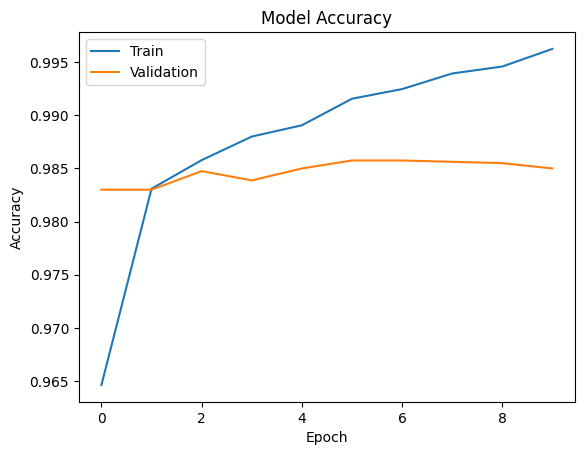

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

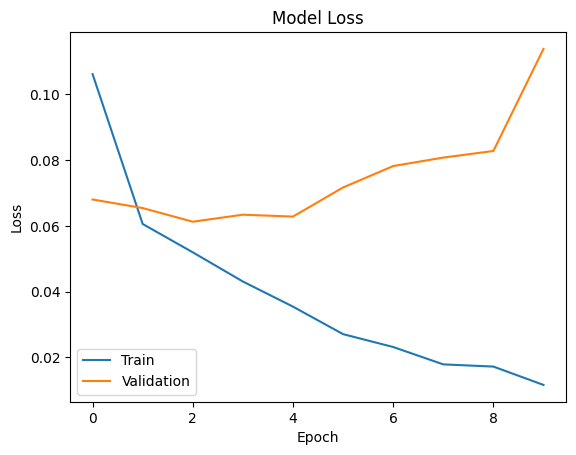

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [24]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.8).astype(int)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[[5006   36]
 [  98 4860]]


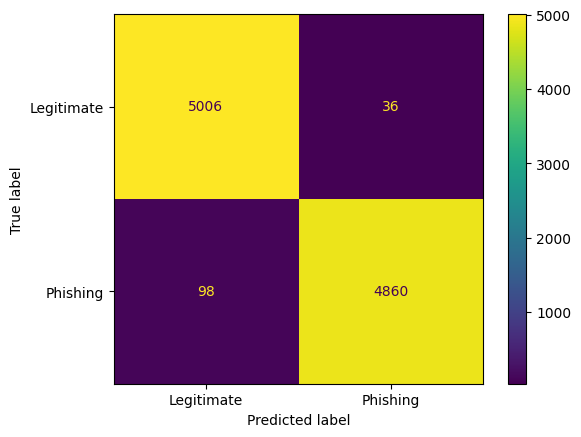

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Legitimate', 'Phishing']
)

disp.plot()
plt.show()

In [26]:
def predict_url(url):
    seq = tokenizer.texts_to_sequences([url])
    pad = pad_sequences(seq, maxlen=200)

    score = model.predict(pad, verbose=0)[0][0]

    if score >= 0.8:
        print(f"Phishing ({score:.4f}) -> Đưa vào Sandbox")
    else:
        print(f"Safe ({score:.4f})")

In [30]:
import pandas as pd

df = pd.read_csv("../dataset/top-1m.csv")

In [34]:
print(df.columns)
print(df.head())

Index(['1', 'google.com'], dtype='object')
   1     google.com
0  2    youtube.com
1  3   facebook.com
2  4      baidu.com
3  5  wikipedia.org
4  6      yahoo.com


In [35]:
import pandas as pd

df = pd.read_csv(
    "../dataset/top-1m.csv",
    header=None,
    names=["rank", "domain"]
)

TRUSTED_DOMAINS = set(df["domain"].str.lower())

In [36]:
print(df.head())
print(df.columns)
print(len(TRUSTED_DOMAINS))

   rank         domain
0     1     google.com
1     2    youtube.com
2     3   facebook.com
3     4      baidu.com
4     5  wikipedia.org
Index(['rank', 'domain'], dtype='object')
1000000


In [37]:
print("google.com" in TRUSTED_DOMAINS)
print("facebook.com" in TRUSTED_DOMAINS)
print("youtube.com" in TRUSTED_DOMAINS)

True
True
True
